# ASVspoof5 Cross-System Evaluation On Other Test Sets (A01-A16)

This notebook reuses the trained logistic-regression models from `train_logistic_asvspoof5.ipynb` and evaluates transfer across system IDs.

Example:
- model `A01` is evaluated on the **test split** of `bonafide vs A02`, `bonafide vs A03`, ..., `bonafide vs A16`

The evaluation is cross-system and can also cross source partitions:
- `A01-A08` target data comes from the `train` source manifest/test split
- `A09-A16` target data comes from the `dev` source manifest/test split

Each target task remains binary:
- `bonafide`
- `target_system`


In [4]:
import gc
import io
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')


In [5]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')

PLAN_BASE = (
    PROJECT_ROOT
    / 'data'
    / 'datasets'
    / 'ASVspoof5_tars'
    / 'ASVspoof5_protocols'
    / 'train_dev_16_systems_outputs'
)

TRAINED_MODELS_BASE = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_train_dev_16_systems'
OUT_BASE = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_train_dev_16_systems_cross_system_eval'
OUT_BASE.mkdir(parents=True, exist_ok=True)

PARTITION_SPECS = {
    'train': {
        'manifest_path': PLAN_BASE / 'train' / 'selected_utterances_plan.csv',
        'embedding_cache': TRAINED_MODELS_BASE / 'train' / 'embeddings_all_selected.npz',
        'systems': [f'A{i:02d}' for i in range(1, 9)],
    },
    'dev': {
        'manifest_path': PLAN_BASE / 'dev' / 'selected_utterances_plan.csv',
        'embedding_cache': TRAINED_MODELS_BASE / 'dev' / 'embeddings_all_selected.npz',
        'systems': [f'A{i:02d}' for i in range(9, 17)],
    },
}

ALL_SYSTEMS = [f'A{i:02d}' for i in range(1, 17)]
SYSTEM_TO_PARTITION = {sys_id: 'train' for sys_id in PARTITION_SPECS['train']['systems']}
SYSTEM_TO_PARTITION.update({sys_id: 'dev' for sys_id in PARTITION_SPECS['dev']['systems']})

INCLUDE_SELF_TASK = False
SAVE_PREDICTIONS = True

print('TRAINED_MODELS_BASE =', TRAINED_MODELS_BASE)
print('OUT_BASE =', OUT_BASE)
for part, spec in PARTITION_SPECS.items():
    print(part, 'manifest =', spec['manifest_path'], '| exists =', spec['manifest_path'].exists())
    print(part, 'embedding_cache =', spec['embedding_cache'], '| exists =', spec['embedding_cache'].exists())


TRAINED_MODELS_BASE = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_dev_16_systems
OUT_BASE = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_dev_16_systems_cross_system_eval
train manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/train_dev_16_systems_outputs/train/selected_utterances_plan.csv | exists = True
train embedding_cache = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_dev_16_systems/train/embeddings_all_selected.npz | exists = True
dev manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/train_dev_16_systems_outputs/dev/selected_utterances_plan.csv | exists = True
dev embedding_cache = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_dev_16_systems/dev/embeddings_all_selected.npz | exists = True


In [6]:
def compute_metrics(y_true, p_spoof, thr=0.5):
    y_hat = (p_spoof >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat).tolist()
    roc = None
    auc = None
    if len(np.unique(y_true)) == 2:
        auc = float(roc_auc_score(y_true, p_spoof))
        fpr, tpr, thresholds = roc_curve(y_true, p_spoof)
        roc = {
            'fpr': fpr.tolist(),
            'tpr': tpr.tolist(),
            'thresholds': thresholds.tolist(),
        }
    return {
        'accuracy': float(accuracy_score(y_true, y_hat)),
        'auc': auc,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_hat, output_dict=True, zero_division=0),
        'roc': roc,
    }


In [7]:
# ===== Load manifests and embedding caches =====
manifest_by_partition = {}
X_by_partition = {}
idx_map_by_partition = {}

for part, spec in PARTITION_SPECS.items():
    manifest_path = spec['manifest_path']
    cache_path = spec['embedding_cache']
    assert manifest_path.exists(), f'Missing manifest: {manifest_path}'
    assert cache_path.exists(), f'Missing embedding cache: {cache_path}'

    df = pd.read_csv(manifest_path)
    req_cols = {'split', 'speaker_id', 'utt_id', 'gender', 'label', 'system_id', 'sample_class', 'target_class'}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f'{part} manifest missing cols: {sorted(missing)}')

    payload = np.load(cache_path, allow_pickle=True)
    X = payload['X']
    utt_ids = payload['utt_ids'].astype(str)

    lut = pd.DataFrame({'utt_id': utt_ids, '_idx': np.arange(len(utt_ids))})
    idx_map = pd.DataFrame({'utt_id': df['utt_id'].astype(str)}).merge(lut, on='utt_id', how='left', validate='one_to_one')
    if idx_map['_idx'].isna().any():
        bad = df.loc[idx_map['_idx'].isna(), 'utt_id'].astype(str).tolist()[:10]
        raise RuntimeError(f'Embedding cache lookup failed for {part}, examples={bad}')

    manifest_by_partition[part] = df.copy().reset_index(drop=True)
    X_by_partition[part] = X[idx_map['_idx'].astype(int).to_numpy()]
    idx_map_by_partition[part] = pd.DataFrame({'utt_id': df['utt_id'].astype(str), '_idx': np.arange(len(df))})

    print(part, 'rows =', len(df), '| embedding rows =', len(X_by_partition[part]))


train rows = 123318 | embedding rows = 123318
dev rows = 123318 | embedding rows = 123318


In [8]:
# ===== Cross-system evaluation =====
rows = []

for source_system in ALL_SYSTEMS:
    source_partition = SYSTEM_TO_PARTITION[source_system]
    source_model_dir = TRAINED_MODELS_BASE / source_partition / source_system
    scaler_path = source_model_dir / 'scaler.pkl'
    clf_path = source_model_dir / 'logistic_regression.pkl'

    if not scaler_path.exists() or not clf_path.exists():
        raise FileNotFoundError(f'Missing model artifacts in {source_model_dir}')

    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    with open(clf_path, 'rb') as f:
        clf = pickle.load(f)

    print(f'\n===== SOURCE MODEL {source_system} ({source_partition}) =====')

    for target_system in ALL_SYSTEMS:
        if (not INCLUDE_SELF_TASK) and (target_system == source_system):
            continue

        target_partition = SYSTEM_TO_PARTITION[target_system]
        tgt_df_all = manifest_by_partition[target_partition]
        X_tgt_all = X_by_partition[target_partition]
        idx_map = idx_map_by_partition[target_partition]

        print(f'-- model {source_system} tested on bonafide vs {target_system} ({target_partition} test split)')

        task_df = tgt_df_all[
            tgt_df_all['split'].eq('test') & tgt_df_all['target_class'].isin(['bonafide', target_system])
        ].copy().reset_index(drop=True)
        if task_df.empty:
            raise RuntimeError(f'Empty task for source={source_system}, target={target_system}')

        pick = task_df[['utt_id']].astype(str).merge(idx_map, on='utt_id', how='left', validate='one_to_one')
        if pick['_idx'].isna().any():
            raise RuntimeError(f'Index mapping failed for {source_system} -> {target_system}')

        X_te = X_tgt_all[pick['_idx'].astype(int).to_numpy()]
        y_te = np.where(task_df['target_class'].eq('bonafide'), 0, 1).astype(int)
        if set(np.unique(y_te)) != {0, 1}:
            raise RuntimeError(f'Target class imbalance in {source_system} -> {target_system}')

        X_te_s = scaler.transform(X_te)
        p_te = clf.predict_proba(X_te_s)[:, 1]
        m_te = compute_metrics(y_te, p_te, thr=0.5)

        pair_dir = OUT_BASE / f'{source_system}_model_on_{target_system}_test'
        pair_dir.mkdir(parents=True, exist_ok=True)

        run_summary = {
            'source_model_system': source_system,
            'source_model_partition': source_partition,
            'target_eval_system': target_system,
            'target_eval_partition': target_partition,
            'test_rows': int(len(task_df)),
            'metrics_test_thr_0_5': m_te,
        }
        (pair_dir / 'run_summary.json').write_text(json.dumps(run_summary, indent=2), encoding='utf-8')

        if SAVE_PREDICTIONS:
            pred = task_df[['split', 'speaker_id', 'utt_id', 'gender', 'label', 'system_id', 'target_class']].copy().reset_index(drop=True)
            pred['label_id'] = y_te
            pred['prob_spoof'] = p_te
            pred['pred_label_id_thr_0_5'] = (p_te >= 0.5).astype(int)
            pred.to_csv(pair_dir / f'predictions_{source_system}_on_{target_system}.csv', index=False)

        if m_te['roc'] is not None:
            roc_df = pd.DataFrame({
                'fpr': m_te['roc']['fpr'],
                'tpr': m_te['roc']['tpr'],
                'threshold': m_te['roc']['thresholds'],
            })
            roc_df.to_csv(pair_dir / 'roc_curve_points.csv', index=False)

        rows.append({
            'source_model_system': source_system,
            'source_model_partition': source_partition,
            'target_eval_system': target_system,
            'target_eval_partition': target_partition,
            'test_n': int(len(y_te)),
            'test_acc': m_te['accuracy'],
            'test_auc': m_te['auc'],
            'test_cm_00': int(m_te['confusion_matrix'][0][0]),
            'test_cm_01': int(m_te['confusion_matrix'][0][1]),
            'test_cm_10': int(m_te['confusion_matrix'][1][0]),
            'test_cm_11': int(m_te['confusion_matrix'][1][1]),
        })

        del X_te, y_te, X_te_s, p_te
        gc.collect()

summary_df = pd.DataFrame(rows).sort_values(['source_model_system', 'target_eval_system']).reset_index(drop=True)
summary_csv = OUT_BASE / 'cross_system_other_test_metrics_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print('Saved:', summary_csv)
display(summary_df)



===== SOURCE MODEL A01 (train) =====
-- model A01 tested on bonafide vs A02 (train test split)
-- model A01 tested on bonafide vs A03 (train test split)
-- model A01 tested on bonafide vs A04 (train test split)
-- model A01 tested on bonafide vs A05 (train test split)
-- model A01 tested on bonafide vs A06 (train test split)
-- model A01 tested on bonafide vs A07 (train test split)
-- model A01 tested on bonafide vs A08 (train test split)
-- model A01 tested on bonafide vs A09 (dev test split)
-- model A01 tested on bonafide vs A10 (dev test split)
-- model A01 tested on bonafide vs A11 (dev test split)
-- model A01 tested on bonafide vs A12 (dev test split)
-- model A01 tested on bonafide vs A13 (dev test split)
-- model A01 tested on bonafide vs A14 (dev test split)
-- model A01 tested on bonafide vs A15 (dev test split)
-- model A01 tested on bonafide vs A16 (dev test split)

===== SOURCE MODEL A02 (train) =====
-- model A02 tested on bonafide vs A01 (train test split)
-- model A02

,source_model_system,source_model_partition,target_eval_system,target_eval_partition,test_n,test_acc,test_auc,test_cm_00,test_cm_01,test_cm_10,test_cm_11
0,A01,train,A02,train,8950,0.993966,0.999977,4421,54,0,4475
1,A01,train,A03,train,8950,0.993966,0.999984,4421,54,0,4475
2,A01,train,A04,train,8950,0.976201,0.997928,4421,54,159,4316
3,A01,train,A05,train,8950,0.983911,0.998772,4421,54,90,4385
4,A01,train,A06,train,8950,0.992737,0.999737,4421,54,11,4464
...,...,...,...,...,...,...,...,...,...,...,...
235,A16,dev,A11,dev,8950,0.716760,0.923164,4466,9,2526,1949
236,A16,dev,A12,dev,8950,0.513296,0.725559,4466,9,4347,128
237,A16,dev,A13,dev,8950,0.767039,0.989790,4466,9,2076,2399
238,A16,dev,A14,dev,8950,0.998101,0.999973,4466,9,8,4467


In [9]:
summary_df = pd.read_csv(OUT_BASE / 'cross_system_other_test_metrics_summary.csv')
display(summary_df.head(20))


,source_model_system,source_model_partition,target_eval_system,target_eval_partition,test_n,test_acc,test_auc,test_cm_00,test_cm_01,test_cm_10,test_cm_11
0,A01,train,A02,train,8950,0.993966,0.999977,4421,54,0,4475
1,A01,train,A03,train,8950,0.993966,0.999984,4421,54,0,4475
2,A01,train,A04,train,8950,0.976201,0.997928,4421,54,159,4316
3,A01,train,A05,train,8950,0.983911,0.998772,4421,54,90,4385
4,A01,train,A06,train,8950,0.992737,0.999737,4421,54,11,4464
5,A01,train,A07,train,8950,0.993966,0.999985,4421,54,0,4475
6,A01,train,A08,train,8950,0.772737,0.972172,4421,54,1980,2495
7,A01,train,A09,dev,8950,0.969609,0.997594,4409,66,206,4269
8,A01,train,A10,dev,8950,0.971285,0.997669,4409,66,191,4284
9,A01,train,A11,dev,8950,0.985363,0.997660,4409,66,65,4410


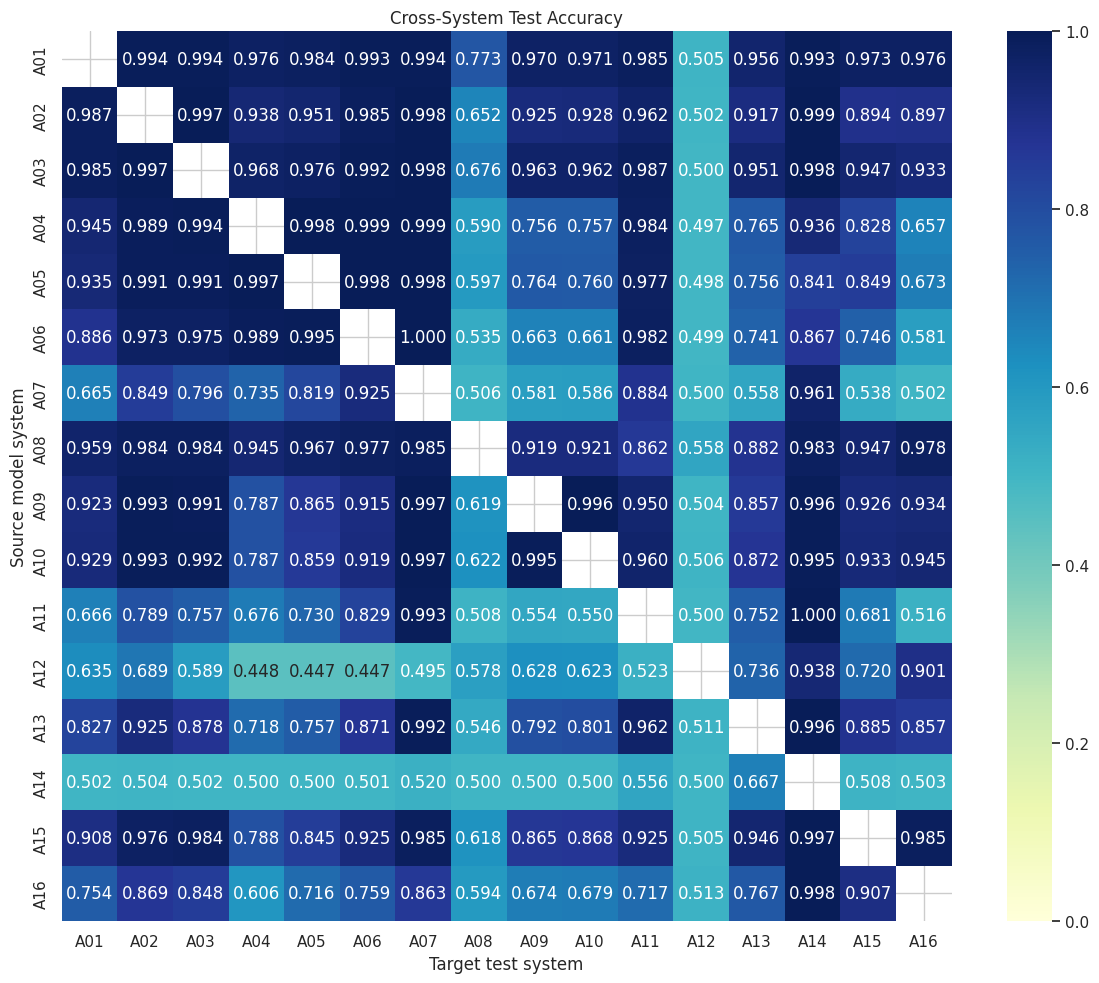

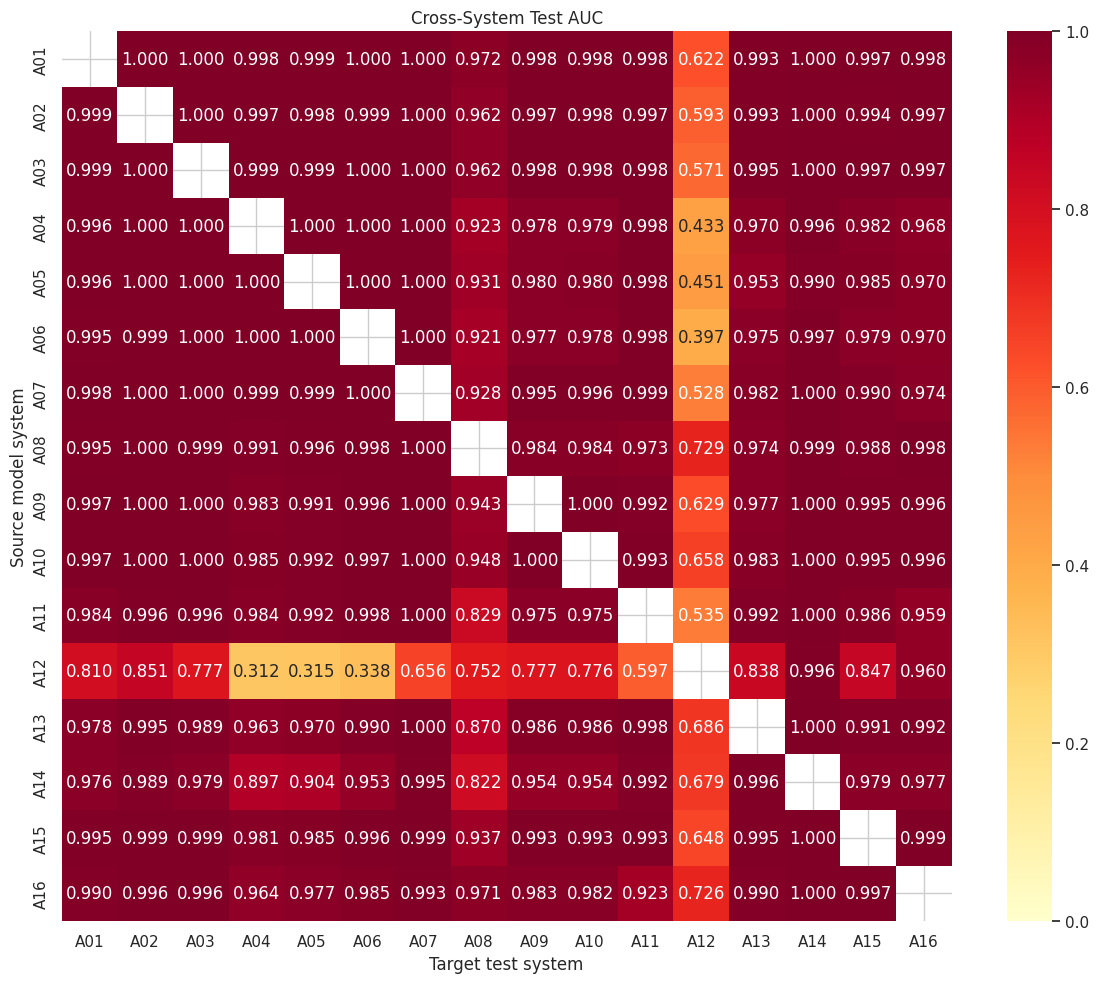

In [10]:
# ===== Accuracy heatmap =====
heat_acc = summary_df.pivot(index='source_model_system', columns='target_eval_system', values='test_acc')
plt.figure(figsize=(12, 10))
sns.heatmap(heat_acc, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0.0, vmax=1.0)
plt.title('Cross-System Test Accuracy')
plt.xlabel('Target test system')
plt.ylabel('Source model system')
plt.tight_layout()
plt.show()

# ===== AUC heatmap =====
heat_auc = summary_df.pivot(index='source_model_system', columns='target_eval_system', values='test_auc')
plt.figure(figsize=(12, 10))
sns.heatmap(heat_auc, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0.0, vmax=1.0)
plt.title('Cross-System Test AUC')
plt.xlabel('Target test system')
plt.ylabel('Source model system')
plt.tight_layout()
plt.show()


In [11]:
source_rank = (
    summary_df.groupby("source_model_system")
    .agg(
        mean_test_acc=("test_acc", "mean"),
        mean_test_auc=("test_auc", "mean"),
        min_test_acc=("test_acc", "min"),
        min_test_auc=("test_auc", "min"),
        n_targets=("target_eval_system", "nunique"),
    )
    .sort_values(["mean_test_auc", "mean_test_acc"], ascending=False)
    .reset_index()
)

top3_auc = source_rank.nlargest(3, ["mean_test_auc", "mean_test_acc"])
top3_acc = source_rank.nlargest(3, ["mean_test_acc", "mean_test_auc"])

display(("### Top 3 source models by mean cross-system AUC"))
display(top3_auc)

display(("### Top 3 source models by mean cross-system accuracy"))
display(top3_acc)

display(("### Full source-model ranking"))
display(source_rank)

'### Top 3 source models by mean cross-system AUC'

,source_model_system,mean_test_acc,mean_test_auc,min_test_acc,min_test_auc,n_targets
0,A08,0.923486,0.973802,0.557989,0.729028,15
1,A01,0.935747,0.971451,0.505251,0.622369,15
2,A10,0.886965,0.969592,0.506257,0.658227,15


'### Top 3 source models by mean cross-system accuracy'

,source_model_system,mean_test_acc,mean_test_auc,min_test_acc,min_test_auc,n_targets
1,A01,0.935747,0.971451,0.505251,0.622369,15
0,A08,0.923486,0.973802,0.557989,0.729028,15
4,A03,0.922108,0.967559,0.499777,0.571169,15


'### Full source-model ranking'

,source_model_system,mean_test_acc,mean_test_auc,min_test_acc,min_test_auc,n_targets
0,A08,0.923486,0.973802,0.557989,0.729028,15
1,A01,0.935747,0.971451,0.505251,0.622369,15
2,A10,0.886965,0.969592,0.506257,0.658227,15
3,A02,0.902190,0.968257,0.501788,0.592850,15
4,A03,0.922108,0.967559,0.499777,0.571169,15
5,A15,0.874726,0.967480,0.505475,0.647872,15
6,A09,0.883590,0.966567,0.503575,0.629185,15
7,A16,0.750965,0.964865,0.513296,0.725559,15
8,A13,0.821289,0.959620,0.510838,0.686230,15
9,A07,0.693579,0.959230,0.500000,0.528054,15


In [12]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

In [13]:
# Use the AUC transfer matrix as the main similarity signal.
auc_matrix = summary_df.pivot(
    index="source_model_system", columns="target_eval_system", values="test_auc"
).loc[ALL_SYSTEMS, ALL_SYSTEMS]
acc_matrix = summary_df.pivot(
    index="source_model_system", columns="target_eval_system", values="test_acc"
).loc[ALL_SYSTEMS, ALL_SYSTEMS]

# Missing cells are only the intentionally skipped diagonal; fill them with 1.0 for clustering.
auc_for_cluster = auc_matrix.copy()
acc_for_cluster = acc_matrix.copy()
for sys_id in ALL_SYSTEMS:
    if pd.isna(auc_for_cluster.loc[sys_id, sys_id]):
        auc_for_cluster.loc[sys_id, sys_id] = 1.0
    if pd.isna(acc_for_cluster.loc[sys_id, sys_id]):
        acc_for_cluster.loc[sys_id, sys_id] = 1.0

display(auc_for_cluster)

target_eval_system,A01,A02,A03,A04,A05,A06,A07,A08,A09,A10,A11,A12,A13,A14,A15,A16
source_model_system,,,,,,,,,,,,,,,,
A01,1.000000,0.999977,0.999984,0.997928,0.998772,0.999737,0.999985,0.972172,0.997594,0.997669,0.997660,0.622369,0.992821,0.999995,0.997345,0.997755
A02,0.999335,1.000000,0.999956,0.997081,0.997990,0.999225,0.999984,0.962042,0.997403,0.997580,0.997004,0.592850,0.993150,0.999989,0.993703,0.996563
A03,0.999241,0.999966,1.000000,0.998519,0.998936,0.999636,0.999990,0.962471,0.998313,0.998499,0.998287,0.571169,0.994864,0.999999,0.996786,0.996718
A04,0.996409,0.999606,0.999887,1.000000,0.999985,0.999999,1.000000,0.922827,0.977979,0.978671,0.998323,0.433373,0.969520,0.996184,0.982348,0.967947
A05,0.996475,0.999739,0.999553,0.999975,1.000000,0.999996,1.000000,0.931464,0.980423,0.980483,0.997722,0.450683,0.953330,0.990269,0.985079,0.970180
A06,0.995476,0.999480,0.999660,0.999824,0.999945,1.000000,0.999997,0.920850,0.977180,0.978017,0.998304,0.396520,0.975020,0.996637,0.978770,0.970167
A07,0.997550,0.999569,0.999866,0.999096,0.999286,0.999899,1.000000,0.928479,0.995376,0.995621,0.999381,0.528054,0.982147,0.999968,0.989938,0.974218
A08,0.994878,0.999601,0.999376,0.991267,0.995863,0.997735,0.999796,1.000000,0.983685,0.983678,0.972566,0.729028,0.973607,0.999418,0.988472,0.998051
A09,0.996626,0.999810,0.999653,0.982718,0.991423,0.996461,0.999980,0.943481,1.000000,0.999954,0.991684,0.629185,0.976682,0.999844,0.995163,0.995836


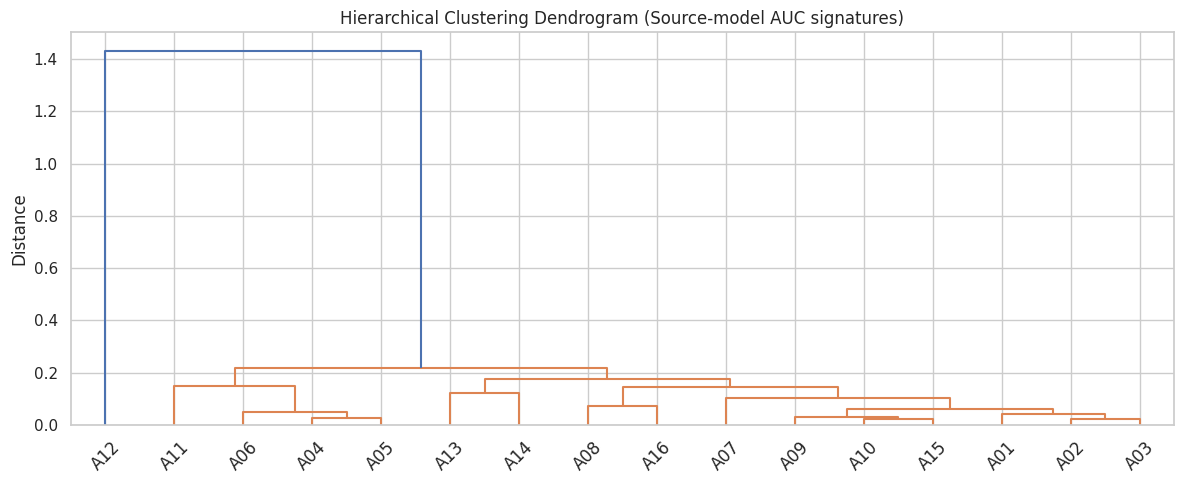

In [14]:
# Hierarchical clustering on source-model transfer signatures.
# Distance is computed between row vectors of the AUC matrix.
source_linkage = linkage(
    pdist(auc_for_cluster.values, metric="euclidean"), method="average"
)
target_linkage = linkage(
    pdist(auc_for_cluster.values.T, metric="euclidean"), method="average"
)

plt.figure(figsize=(12, 5))
dendrogram(source_linkage, labels=auc_for_cluster.index.tolist(), leaf_rotation=45)
plt.title("Hierarchical Clustering Dendrogram (Source-model AUC signatures)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import silhouette_score

# Evaluate several flat-cluster cuts and pick the best one dynamically.
candidate_k = list(range(3, 10))
score_rows = []
cluster_results = {}
X_cluster = auc_for_cluster.values

for k in candidate_k:
    labels = fcluster(source_linkage, t=k, criterion="maxclust")
    n_found = len(np.unique(labels))
    score = np.nan
    if n_found >= 2 and n_found < len(X_cluster):
        score = float(silhouette_score(X_cluster, labels, metric="euclidean"))
    score_rows.append(
        {
            "k_requested": k,
            "k_found": int(n_found),
            "silhouette_score": score,
        }
    )
    cluster_results[k] = labels

cluster_score_df = (
    pd.DataFrame(score_rows).sort_values("k_requested").reset_index(drop=True)
)
display(("### Silhouette-based cluster-count selection"))
display(cluster_score_df)

valid_scores = cluster_score_df.dropna(subset=["silhouette_score"]).copy()
if valid_scores.empty:
    raise RuntimeError(
        "No valid silhouette scores were produced for the candidate cluster counts."
    )

best_row = valid_scores.sort_values(
    ["silhouette_score", "k_found"], ascending=[False, True]
).iloc[0]
BEST_K = int(best_row["k_requested"])
BEST_LABELS = cluster_results[BEST_K]

display(
    (
        f'### Selected cluster count: `k = {BEST_K}` (silhouette = {best_row["silhouette_score"]:.4f})'
    )
)

cluster_df = (
    pd.DataFrame(
        {
            "system_id": auc_for_cluster.index,
            "cluster_id": BEST_LABELS,
        }
    )
    .sort_values(["cluster_id", "system_id"])
    .reset_index(drop=True)
)
display(cluster_df)

cluster_summary = (
    cluster_df.groupby("cluster_id")["system_id"]
    .apply(list)
    .reset_index(name="systems")
)
display(cluster_summary)

'### Silhouette-based cluster-count selection'

,k_requested,k_found,silhouette_score
0,3,3,0.414774
1,4,4,0.371913
2,5,5,0.369114
3,6,6,0.425967
4,7,7,0.375997
5,8,8,0.319720
6,9,9,0.262537


'### Selected cluster count: `k = 6` (silhouette = 0.4260)'

,system_id,cluster_id
0,A04,1
1,A05,1
2,A06,1
3,A11,2
4,A13,3
5,A14,3
6,A08,4
7,A16,4
8,A01,5
9,A02,5


,cluster_id,systems
0,1,"[A04, A05, A06]"
1,2,[A11]
2,3,"[A13, A14]"
3,4,"[A08, A16]"
4,5,"[A01, A02, A03, A07, A09, A10, A15]"
5,6,[A12]


## Cluster Interpretation

The clustering is based on **transfer behavior** in the cross-system AUC matrix, not on the attack descriptions directly.  
The descriptions below are therefore an **interpretation** of the discovered groups, not a hard proof of causality.

### Why the structure looks like this

- **A12 is expected to separate from the others.**  
  A12 is a simplified **unit-selection TTS** system. It does not use the same kind of neural acoustic decoder / neural vocoder stack used by most of the other attacks. Instead, it concatenates speaker-specific phone units with random selection among candidates. That makes it qualitatively different from the modern neural TTS/VC systems, so it is reasonable that its transfer signature is isolated.

- **A01, A02, A03 should be close to each other.**  
  These three are the same **Glow-TTS + HiFi-GAN** pipeline, with the main difference being the speaker encoder:
  - A01: ECAPA-TDNN
  - A02: ResNet-34
  - A03: TDNN-Y-vector
  Because the core acoustic decoder and vocoder are the same, the clustering is expected to place them close together.

- **A04, A05, A06 should also be close to each other.**  
  These three are the same **Grad-TTS + HiFi-GAN** family, again differing mostly in the speaker encoder:
  - A04: ECAPA-TDNN
  - A05: ResNet-34
  - A06: TDNN-Y-vector
  So if they cluster together, that is consistent with the architecture description.

- **A09 and A10 should be close.**  
  A10 is described as almost identical to A09, with relatively small changes in pitch/energy prediction and vocoder size. Strong transfer similarity between them is therefore expected.

- **A13, A15, A16 are all VC systems, while most of A01-A12 are TTS systems.**  
  If some of these systems group together or sit near each other in the dendrogram, that may reflect shared artifacts of **voice conversion** rather than text-to-speech generation.

- **A14 can appear close to VITS-like systems.**  
  A14 is based on **YourTTS**, which itself is built on **VITS**, so similarity between A14 and VITS-like behavior is plausible.

### Reading the discovered clusters

A reasonable interpretation strategy is:
- if two systems cluster together and their descriptions differ only by speaker encoder or small implementation details, that supports the idea that the classifier is capturing the shared synthesis pipeline rather than only the speaker encoder;
- if one system separates strongly from the others, that suggests it leaves a distinct artifact pattern in the embeddings;
- if a system from one family clusters with another family, that may indicate that the learned detector is reacting more to the **vocoder / waveform artifacts / output statistics** than to the nominal TTS-vs-VC label.

### Practical conclusion

The clustering is useful because it tells us which attacks behave similarly **from the detector's point of view**.  
This is not exactly the same as grouping attacks by their official textual description, but when the two agree, it strengthens the interpretation.
